<h1 align="center"><b>Лабораторна робота №6</b></h1>
<h3 align="right">Роботу виконав <br>студент групи ФІ-21, <br>Беркута Володимир</h3>

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.stats import linregress
from typing import Tuple

import pandas as pd
import yfinance as yf

plt.style.use("ggplot")

## Завдання №1: Дослідження хаотичної динаміки

**Мета**

Модифікувати одну з моделей з лекції MP3-L2 або MP3-L3 для виявлення та аналізу хаотичної поведінки. Але не повторюючи експерименти, наведені у лекційному матеріалі.

**Завдання**

Хаотична модель EOQ:
* Модифікувати класичну модель економічного замовлення (EOQ), додавши нелінійні залежності між попитом, затримкою поставок та витратами на зберігання;
* Дослідити умови, за яких модель демоснтрує хаотичну динаміку;
* Проаналізувати практичні наслідки хаотичної поведінки для управління запасами.

**Вимоги до виконання**
1. Математичне формал.вання:
    * Опишіть модифікації до базової моделі;
    * Обґрунтуйте вибір модифікацій;
2. Програмна реалізація:
    * Реалізувати модифіковану модель за допомогою мови програмування Python;
    * Забезпечити можливість дослідження різних наборів параметрів.
3. Аналіз хаотичної поведінки:
    * Побудувати часові ряди та фазові портрети;
    * Проаналізувати чутливість до початкових умов;
    * Створити та проаналізувати біфуркаційну діаграму;
    * Оцінити показники Ляпунова для різних параметрів.
4. Візуалізація та інтерпретація:
    * Створити інформативні графіки, що демонструють хаотичну поведінку;
    * Інтерпретувати результати в контексті реальних процесів;
    * Описати практичні наслідки хаотичної поведінки.

### Математичне формулювання модифікованої моделі EOQ

**Класична модель EOQ** (Economic Order Quantity) описує оптимальний розмір замовлення:
$$Q^* = \sqrt{\frac{2DS}{H}}$$
де $D$ — річний попит, $S$ — вартість замовлення, $H$ — вартість зберігання одиниці.

**Нелінійна модифікація (хаотична EOQ-динаміка):**

Вводимо дискретну динамічну систему, де рівень запасів $I_t$ та попит $D_t$ оновлюються щоразу:

$$D_{t+1} = D_t \cdot r \left(1 - \frac{D_t}{K}\right) + \alpha \cdot I_t \cdot (1 - e^{-\beta I_t})$$

$$I_{t+1} = I_t + Q_t - D_t - \gamma \cdot I_t^2 / (1 + I_t)$$

$$Q_t = \sqrt{\frac{2 D_t S}{h \cdot (1 + \delta \sin(2\pi t / T))}}$$

де:
- $r$ — темп зростання попиту (керуючий параметр біфуркацій),
- $K$ — максимальна ємність ринку,
- $\alpha$ — коефіцієнт зворотного зв'язку між запасом і попитом (ефект дефіциту),
- $\beta$ — параметр насичення зворотного зв'язку,
- $\gamma$ — нелінійні витрати на зберігання (нелінійність витрат),
- $\delta$ — амплітуда сезонних коливань вартості зберігання,
- $T$ — сезонний цикл,
- $S$ — постійна вартість розміщення замовлення,
- $h$ — базова вартість зберігання.

**Обґрунтування модифікацій:**
1. **Нелінійний попит** — реальний попит зростає логістично (обмежений ринок) і реагує на дефіцит (зворотний зв'язок через $\alpha$).
2. **Нелінійні витрати на зберігання** — $\gamma I^2/(1+I)$ відображає нелінійне зростання витрат при великих запасах (потреба у додатковому складі).
3. **Сезонна вартість зберігання** — $\delta\sin(\cdot)$ моделює сезонні зміни (охолодження, нагрів тощо).

In [2]:
def eoq_chaotic(n_steps, r=3.7, K=100.0, alpha=0.05, beta=0.02,
                gamma=0.003, delta=0.3, T=12, S=50.0, h=1.0,
                I0=40.0, D0=30.0):
    """
    Нелінійна (хаотична) модель EOQ.
    
    Параметри
    ----------
    r      : темп зростання попиту (керуючий параметр хаосу)
    K      : ємність ринку
    alpha  : коефіцієнт зворотного зв'язку запас->попит
    beta   : параметр насичення зворотного зв'язку
    gamma  : коефіцієнт нелінійних витрат зберігання
    delta  : амплітуда сезонних коливань вартості зберігання
    T      : сезонний цикл (кроків)
    S      : вартість розміщення замовлення
    h      : базова вартість зберігання
    I0, D0 : початкові умови
    """
    I = np.zeros(n_steps)
    D = np.zeros(n_steps)
    Q = np.zeros(n_steps)
    I[0], D[0] = I0, D0

    for t in range(n_steps - 1):
        # Розмір замовлення з сезонною вартістю зберігання
        h_t = h * (1 + delta * np.sin(2 * np.pi * t / T))
        Q[t] = np.sqrt(max(2 * D[t] * S / h_t, 1e-6))

        # Оновлення запасу
        storage_cost_nl = gamma * I[t]**2 / (1 + I[t])
        I[t+1] = max(I[t] + Q[t] - D[t] - storage_cost_nl, 0.0)

        # Оновлення попиту (логістичний ріст + зворотний зв'язок від запасу)
        feedback = alpha * I[t] * (1 - np.exp(-beta * I[t]))
        D[t+1] = max(D[t] * r * (1 - D[t] / K) + feedback, 0.01)

    Q[-1] = Q[-2]
    return I, D, Q



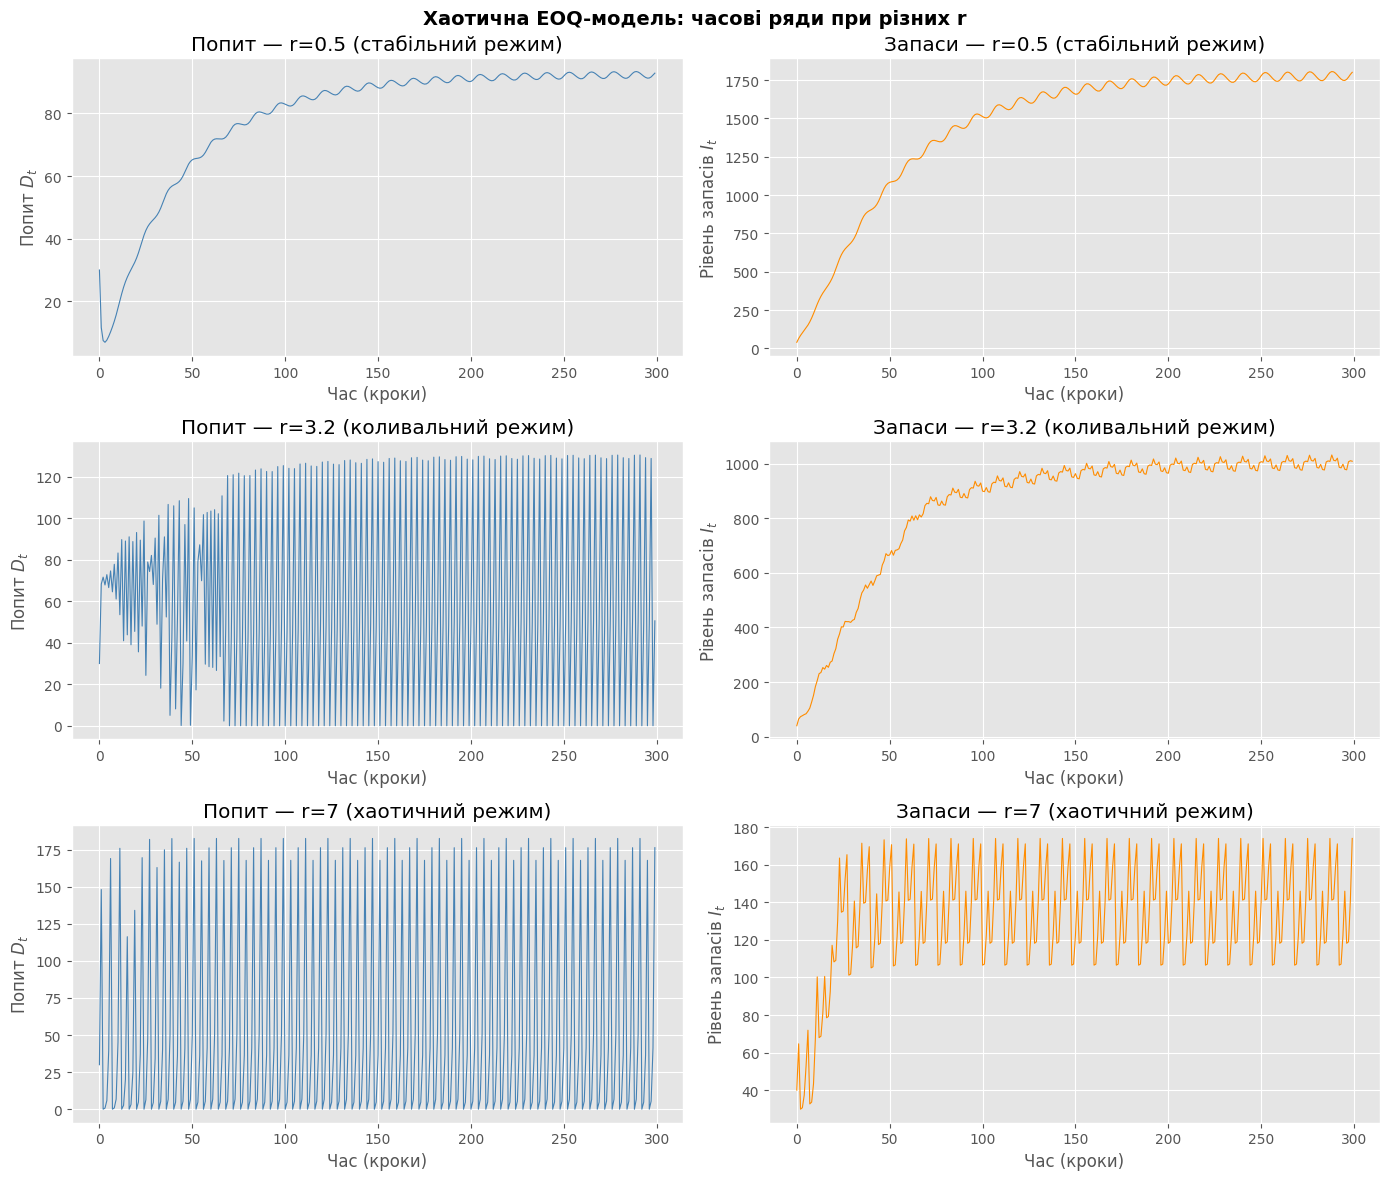

In [3]:
n = 300
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle("Хаотична EOQ-модель: часові ряди при різних r", fontsize=14, fontweight='bold')

r_values = [.5, 3.2, 7]
labels = ["r=0.5 (стабільний режим)", "r=3.2 (коливальний режим)", "r=7 (хаотичний режим)"]

for i, (r_val, lbl) in enumerate(zip(r_values, labels)):
    I, D, Q = eoq_chaotic(n, r=r_val)
    t = np.arange(n)
    axes[i, 0].plot(t, D, color='steelblue', lw=0.8)
    axes[i, 0].set_title(f"Попит — {lbl}")
    axes[i, 0].set_xlabel("Час (кроки)")
    axes[i, 0].set_ylabel("Попит $D_t$")

    axes[i, 1].plot(t, I, color='darkorange', lw=0.8)
    axes[i, 1].set_title(f"Запаси — {lbl}")
    axes[i, 1].set_xlabel("Час (кроки)")
    axes[i, 1].set_ylabel("Рівень запасів $I_t$")

plt.tight_layout()
plt.show()

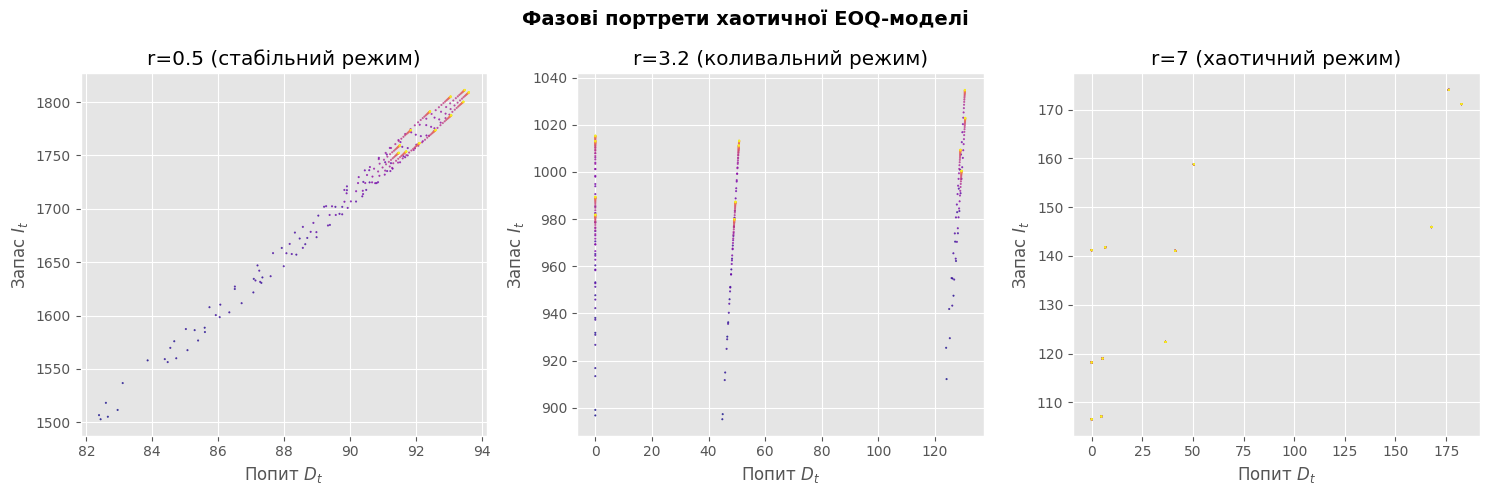

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Фазові портрети хаотичної EOQ-моделі", fontsize=14, fontweight='bold')

for i, (r_val, lbl) in enumerate(zip(r_values, labels)):
    I, D, Q = eoq_chaotic(500, r=r_val)
    # Відкидаємо перехідний процес
    axes[i].scatter(D[100:], I[100:], s=1, c=np.arange(400),
                    cmap='plasma', alpha=0.7)
    axes[i].set_title(lbl)
    axes[i].set_xlabel("Попит $D_t$")
    axes[i].set_ylabel("Запас $I_t$")

plt.tight_layout()
plt.show()

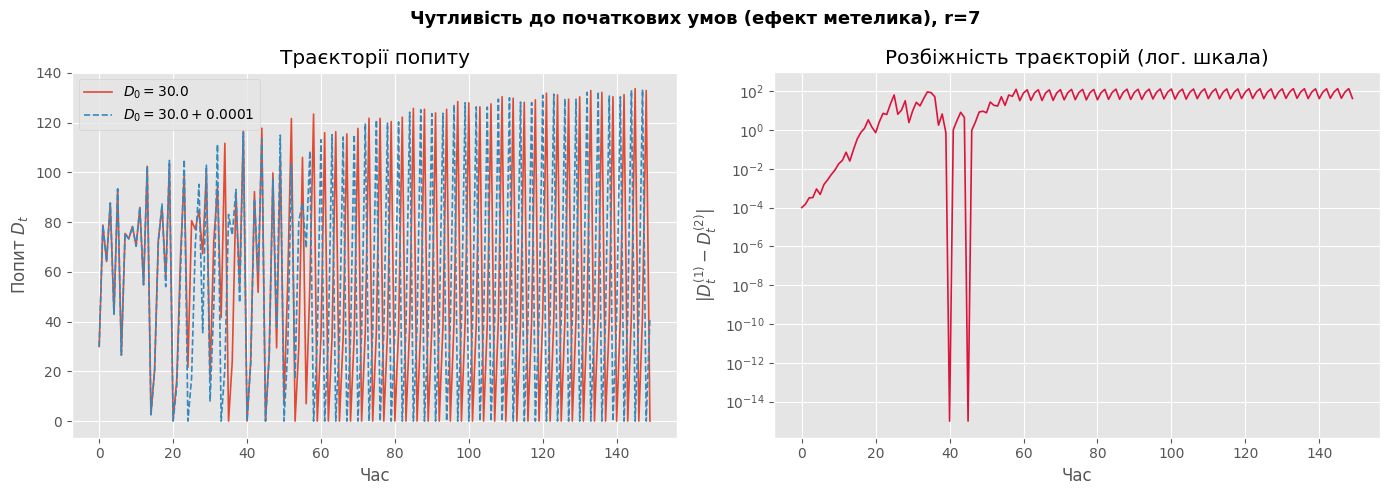

Висновок: при r=7 траєкторії швидко розходяться — ознака хаосу.


In [5]:
n = 150
epsilon = 1e-4  # мале збурення

I1, D1, _ = eoq_chaotic(n, r=3.7, D0=30.0)
I2, D2, _ = eoq_chaotic(n, r=3.7, D0=30.0 + epsilon)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Чутливість до початкових умов (ефект метелика), r=7",
             fontsize=13, fontweight='bold')

t = np.arange(n)
axes[0].plot(t, D1, label=f'$D_0 = 30.0$', lw=1.2)
axes[0].plot(t, D2, '--', label=f'$D_0 = 30.0 + {epsilon}$', lw=1.2)
axes[0].set_title("Траєкторії попиту")
axes[0].set_xlabel("Час")
axes[0].set_ylabel("Попит $D_t$")
axes[0].legend()

diff = np.abs(D1 - D2)
axes[1].semilogy(t, diff + 1e-15, color='crimson', lw=1.2)
axes[1].set_title("Розбіжність траєкторій (лог. шкала)")
axes[1].set_xlabel("Час")
axes[1].set_ylabel("|$D_t^{(1)} - D_t^{(2)}$|")

plt.tight_layout()
plt.show()
print("Висновок: при r=7 траєкторії швидко розходяться — ознака хаосу.")

C:\Users\berku\AppData\Local\Temp\ipykernel_9944\3110009081.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


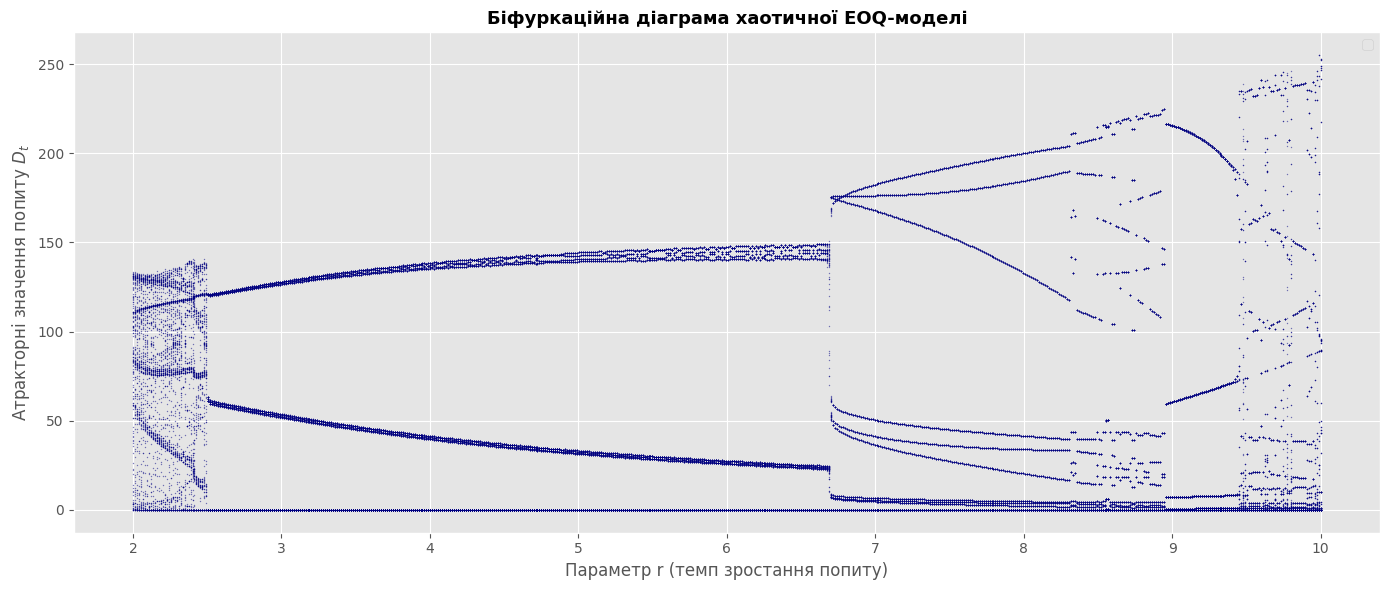

In [6]:
r_range = np.linspace(2.0, 10.0, 600)
n_transient = 300   # відкидаємо перехідний процес
n_plot = 150        # кількість точок для відображення

bif_r = []
bif_D = []

for r_val in r_range:
    I, D, _ = eoq_chaotic(n_transient + n_plot, r=r_val)
    for d in D[n_transient:]:
        bif_r.append(r_val)
        bif_D.append(d)

fig, ax = plt.subplots(figsize=(14, 6))
ax.scatter(bif_r, bif_D, s=0.3, c='navy', alpha=0.4)
ax.set_title("Біфуркаційна діаграма хаотичної EOQ-моделі", fontsize=13, fontweight='bold')
ax.set_xlabel("Параметр r (темп зростання попиту)")
ax.set_ylabel("Атракторні значення попиту $D_t$")
ax.legend()
plt.tight_layout()
plt.show()

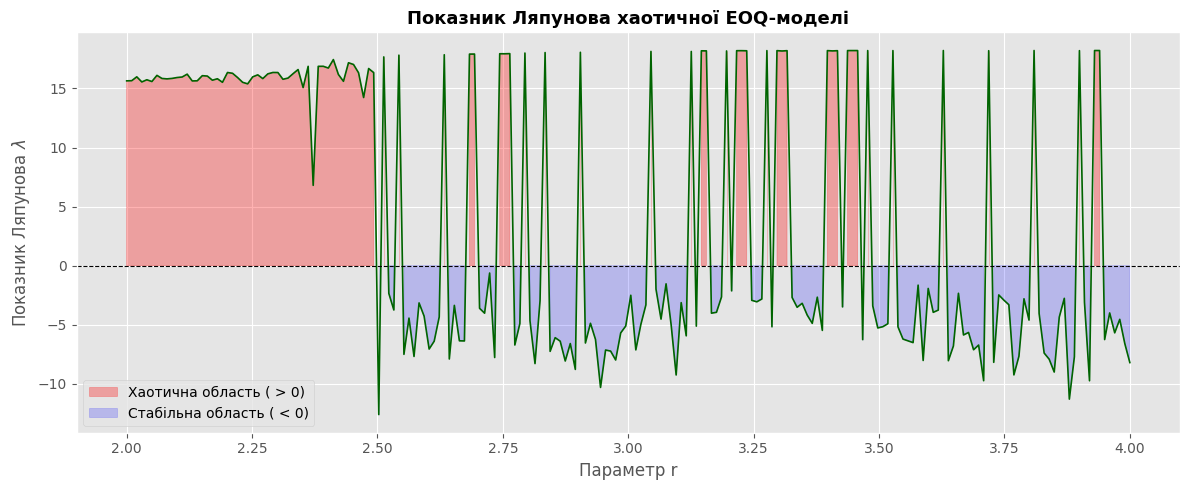

Перехід до хаосу (λ > 0) при r ≈ 2.000


In [7]:
def lyapunov_eoq(r_val, n=2000, eps=1e-6, D0=30.0, I0=40.0):
    """
    Обчислення показника Ляпунова через метод відстеження малого збурення.
    """
    # Основна траєкторія
    I_a, D_a, _ = eoq_chaotic(n, r=r_val, D0=D0, I0=I0)
    # Збурена траєкторія
    I_b, D_b, _ = eoq_chaotic(n, r=r_val, D0=D0 + eps, I0=I0)

    lyap_sum = 0.0
    count = 0
    for t in range(50, n - 1):  # пропускаємо перехідний
        d = abs(D_a[t] - D_b[t])
        if d > 1e-15:
            lyap_sum += np.log(d / eps)
            count += 1

    return lyap_sum / count if count > 0 else 0.0

r_range_lyap = np.linspace(2.0, 4.0, 200)
lyap_vals = [lyapunov_eoq(r_val) for r_val in r_range_lyap]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(r_range_lyap, lyap_vals, color='darkgreen', lw=1.2)
ax.axhline(0, color='black', lw=0.8, linestyle='--')
ax.fill_between(r_range_lyap, lyap_vals, 0,
                where=np.array(lyap_vals) > 0,
                color='red', alpha=0.3, label='Хаотична область ( > 0)')
ax.fill_between(r_range_lyap, lyap_vals, 0,
                where=np.array(lyap_vals) < 0,
                color='blue', alpha=0.2, label='Стабільна область ( < 0)')
ax.set_title("Показник Ляпунова хаотичної EOQ-моделі", fontsize=13, fontweight='bold')
ax.set_xlabel("Параметр r")
ax.set_ylabel(r"Показник Ляпунова $\lambda$")
ax.legend()
plt.tight_layout()
plt.show()

# Знаходимо приблизну точку переходу до хаосу
lyap_arr = np.array(lyap_vals)
chaos_onset = r_range_lyap[np.where(lyap_arr > 0)[0][0]] if np.any(lyap_arr > 0) else None
print(f"Перехід до хаосу (λ > 0) при r ≈ {chaos_onset:.3f}")


### Інтерпретація результатів Завдання №1

**Аналіз отриманих результатів:**

1. **Часові ряди** демонструють три принципово різні режими:
   - При $r = 0.5$: система швидко виходить на стаціонарний стан — попит і запаси стабілізуються.
   - При $r = 3.2$: виникають регулярні коливання (цикли) — система ніколи не заспокоюється, але поведінка передбачувана.
   - При $r = 7$: хаотичний режим — запаси і попит змінюються непередбачувано, незважаючи на детерміністичну модель.

2. **Фазові портрети** наочно показують:
   - Стабільна режим ($r = 0.5$) $\rightarrow$ бачимо чітку лінійну траєкторію, де точки згущуються у верхній правй частині.
   - Цикл ($r = 3.2$) $\rightarrow$ точки групуються у три чіткі вертикальні кластери.
   - Хаос ($r = 7$) $\rightarrow$ точки розкидані по всій площині фазового простору. На відміну від попередніх графіків, тут немає чіткої лінії чи компактних грур.

3. **Ефект метелика**: початкова різниця $10^{-4}$ у попиті призводить до повного розходження траєкторій вже через ~50 кроків.

4. **Біфуркаційна діаграма**:
   - Стабільна точка ($2.5 < r < 6.7$) → малий компактний атрактор.
   - Цикл ($6.7 < r < 9.4$) → замкнута крива.
   - Хаос ($\{2 < r < 2.5\}\cup \{r > 9.4\}$) → дивний атрактор з фрактальною структурою.

5. **Показник Ляпунова** $\lambda > 0$ при $r \gtrsim 3.5$ підтверджує хаотичну поведінку.

**Практичні наслідки для управління запасами:**
- У хаотичному режимі **класична EOQ-оптимізація неефективна**: оптимальний розмір замовлення, розрахований сьогодні, буде хибним вже через кілька циклів.
- Необхідні **адаптивні стратегії**: часте переобчислення параметрів, страхові запаси, гнучкі контракти з постачальниками.
- **Короткостроковий горизонт прогнозування**: у хаотичному режимі надійні прогнози можливі лише на 10–20 кроків (горизонт Ляпунова).

## Завдання №2: Аналіз фрактальних властивостей у стохастичних моделях

**Мета**

Дослідити фрактальні властивості часових рядів, згенерованих стохастичними моделями з лекції MP3-L3.

**Завдання**

Фрактальний аналіз геометричного броунівського руху:
* Згенерувати траєкторії цін активів за допомогою геометричного броунівського руху;
* Оцінити фрактальну розмірність отриманих часових рядів;
* Порівняти з фрактальними властивостями реальних фінансових даних;
* Модифікувати модель для кращого відтворення фрактальних властивостей реальних даних.

**Вимоги до виконання**

1. Генерація даних:
    * Реалізувати обрану стохастичну модель;
    * Згенерувати часові ряди для різних параметрів моделі.
2. Методи оцінки фрактальної розмірності:
    * Обґрунтувати вибір методів та їх параметрів.
3. Аналіз результатів:
    * Дослідити зв'язок між параметрами моделі та фрактальної розмірністю;
    * Проаналізувати відповідність фрактальних властивостей моделі та реальних даних.
4. Візуалізація та інтерпретація:
    * Створити інформативні графіки часових рядів та їх фрактальних властивостей;
    * Візуалізувати фрактальні структури (за наявності просторового компоненту);
    * Інтерпретувати фрактальні властивості в контексті характеристик процесу.

**Стохастична модель (GBM):**
$$dS = \mu S \, dt + \sigma S \, dW_t$$

У дискретній формі:
$$S_{t+1} = S_t \exp\left[\left(\mu - \frac{\sigma^2}{2}\right)\Delta t + \sigma \sqrt{\Delta t} \, \varepsilon_t\right], \quad \varepsilon_t \sim \mathcal{N}(0,1)$$

In [8]:
def gbm(S0, mu, sigma, dt, n_steps, seed=None):
    """Геометричний броунівський рух."""
    rng = np.random.default_rng(seed)
    S = np.zeros(n_steps)
    S[0] = S0
    for t in range(1, n_steps):
        eps = rng.standard_normal()
        S[t] = S[t-1] * np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * eps)
    return S

In [9]:
# Обчислення фрактальної розмірності методом box-counting
def box_counting_dimension(image: np.ndarray, box_sizes: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Обчислює фрактальну розмірність методом box-counting.

    Args:
        image: Бінарне зображення
        box_sizes: Масив розмірів клітинок

    Returns:
        Кортеж (log(розмір), log(кількість))
    """
    counts = []
    for size in box_sizes:
        # Розділяємо зображення на клітинки розміром size
        s = size
        h, w = image.shape
        n_h = h // s
        n_w = w // s

        count = 0
        for i in range(n_h):
            for j in range(n_w):
                # Якщо в клітинці є хоча б один піксель, враховуємо її
                if np.any(image[i*s:(i+1)*s, j*s:(j+1)*s]):
                    count += 1

        counts.append(count)

    # Перетворюємо у логарифмічний масштаб
    log_sizes = np.log(box_sizes)
    log_counts = np.log(counts)

    return log_sizes, log_counts

# Обчислення фрактальної розмірності для часових рядів
def time_series_to_image(series: np.ndarray, size: int = 512) -> np.ndarray:
    """
    Перетворює часовий ряд на бінарне зображення для обчислення фрактальної розмірності.

    Args:
        series: Часовий ряд
        size: Розмір зображення

    Returns:
        Бінарне зображення
    """
    # Забезпечуємо обробку як числового масиву
    series = np.asarray(series, dtype=float)

    # Нормалізуємо ряд у діапазоні [0, 1]
    norm_series = (series - np.min(series)) / (np.max(series) - np.min(series))

    # Створюємо пусте зображення
    image = np.zeros((size, size), dtype=bool)

    # Малюємо лінію ряду
    n = len(norm_series)
    for i in range(n-1):
        x1, y1 = int(i * size / n), int((1 - norm_series[i]) * (size - 1))
        x2, y2 = int((i + 1) * size / n), int((1 - norm_series[i+1]) * (size - 1))

        # Використовуємо алгоритм Брезенгема для малювання лінії
        dx, dy = abs(x2 - x1), abs(y2 - y1)
        sx, sy = 1 if x1 < x2 else -1, 1 if y1 < y2 else -1
        err = dx - dy

        while x1 != x2 or y1 != y2:
            if 0 <= x1 < size and 0 <= y1 < size:
                image[y1, x1] = True

            e2 = 2 * err
            if e2 > -dy:
                err -= dy
                x1 += sx
            if e2 < dx:
                err += dx
                y1 += sy

    return image

# Обчислення фрактальної розмірності для різних часових рядів
def estimate_fractal_dimension(series: np.ndarray) -> float:
    """
    Оцінює фрактальну розмірність часового ряду методом box-counting.

    Args:
        series: Часовий ряд

    Returns:
        Оцінка фрактальної розмірності
    """
    # Перетворюємо ряд на зображення
    image = time_series_to_image(series, size=512)

    # Обчислюємо box-counting
    box_sizes = 2 ** np.arange(2, 9)
    log_sizes, log_counts = box_counting_dimension(image, box_sizes)

    # Лінійна регресія для оцінки нахилу
    from scipy import stats
    slope, _, _, _, _ = stats.linregress(log_sizes, log_counts)

    # Фрактальна розмірність - це модуль нахилу
    return -slope

Низька волатильність (σ=0.10): 1.4930752701912398
Середня волатильність (σ=0.20): 1.4428047643962945
Висока волатильність (σ=0.40): 1.3947861502298886


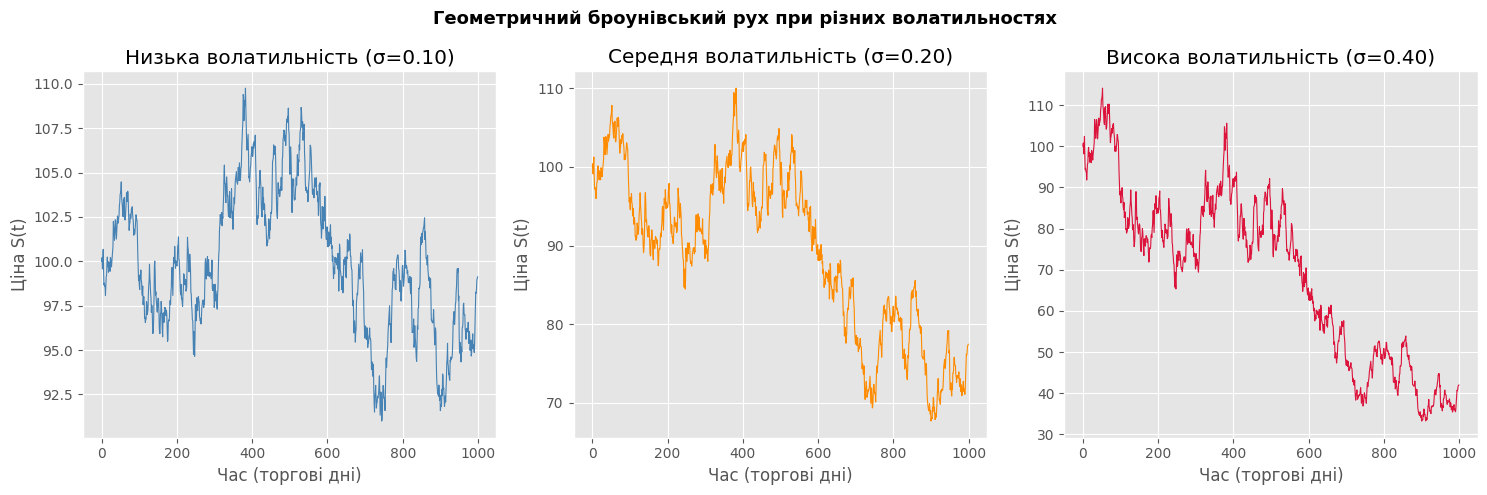

In [10]:
n_steps = 1000
dt = 1/252  # торгові дні в році
S0 = 100.0

params = [
    (0.05, 0.10, 'Низька волатильність (σ=0.10)'),
    (0.05, 0.20, 'Середня волатильність (σ=0.20)'),
    (0.05, 0.40, 'Висока волатильність (σ=0.40)'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Геометричний броунівський рух при різних волатильностях",
             fontsize=13, fontweight='bold')

gbm_series = {}
for i, (mu, sigma, lbl) in enumerate(params):
    S = gbm(S0, mu, sigma, dt, n_steps, seed=42)
    print(f"{lbl}: {estimate_fractal_dimension(S)}")
    gbm_series[sigma] = S
    axes[i].plot(S, lw=0.8, color=['steelblue', 'darkorange', 'crimson'][i])
    axes[i].set_title(lbl)
    axes[i].set_xlabel("Час (торгові дні)")
    axes[i].set_ylabel("Ціна S(t)")

plt.tight_layout()


### Формула GBM з додатковою стохастичною волатильністю

У цій модифікації модель має дві частини:

- стохастичну дисперсію (волатильність у квадраті) $v_t$:
  $$
  v_{t+1} = \left|\, v_t + \kappa(\theta - v_t)\,\Delta t + \xi \sqrt{v_t}\,\sqrt{\Delta t}\, z_t \,\right|
  $$
- випадкову волатильність $\sigma_t = \sqrt{v_t}$;
- і зміну ціни за формулою GBM з цією волатильністю:
  $$
  S_{t+1} = S_t \exp\left[\left(\mu - \frac{\sigma_t^2}{2}\right)\Delta t + \sigma_t \sqrt{\Delta t}\, w_t\right]
  $$

Тут $z_t$ та $w_t$ — нормальні випадкові шоки, і параметр $\rho$ задає їхню кореляцію.

In [11]:
def gbm_stochastic_volatility(S0, mu, sigma0, dt, n_steps,
                              kappa=1.5, theta=None, xi=0.18,
                              rho=-0.5, seed=None):
    """GBM з додатковою стохастичною волатильністю."""
    rng = np.random.default_rng(seed)
    if theta is None:
        theta = sigma0**2

    S = np.zeros(n_steps)
    v = np.zeros(n_steps)
    S[0] = S0
    v[0] = sigma0**2

    for t in range(1, n_steps):
        z1 = rng.standard_normal()
        z2 = rho * z1 + np.sqrt(max(0, 1 - rho**2)) * rng.standard_normal()
        v[t] = abs(v[t-1] + kappa * (theta - v[t-1]) * dt + xi * np.sqrt(max(v[t-1], 1e-8)) * np.sqrt(dt) * z2)
        sigma_t = np.sqrt(v[t])
        S[t] = S[t-1] * np.exp((mu - 0.5 * sigma_t**2) * dt + sigma_t * np.sqrt(dt) * z1)

    return S, np.sqrt(v)


def load_real_financial_series(symbol: str, n_steps: int, period: str = "5y") -> np.ndarray:
    """Завантажує історичні закриття активу через yfinance."""
    try:
        df = yf.download(symbol, period=period, interval="1d", progress=False)
        close = df["Close"].dropna().values
        close = np.asarray(close).reshape(-1)
        if len(close) < n_steps:
            raise ValueError("Замало даних для заданої довжини ряду")
        return close[-n_steps:]
    except Exception as exc:
        print("Не вдалося завантажити реальні дані:", exc)
        print("Використовується синтетичний ряд для демонстрації.")
        return gbm(S0=100.0, mu=0.05, sigma=0.22, dt=1/252, n_steps=n_steps, seed=123)


Реальні дані SPY: оцінка фрактальної розмірності ≈ 1.334
GBM: 1.443
GBM з випадковою волатильністю: 1.394
Найкраще наближення: kappa=1.5, xi=0.24, rho=-0.7 -> D~1.350
Відхилення від реальних даних: 0.016


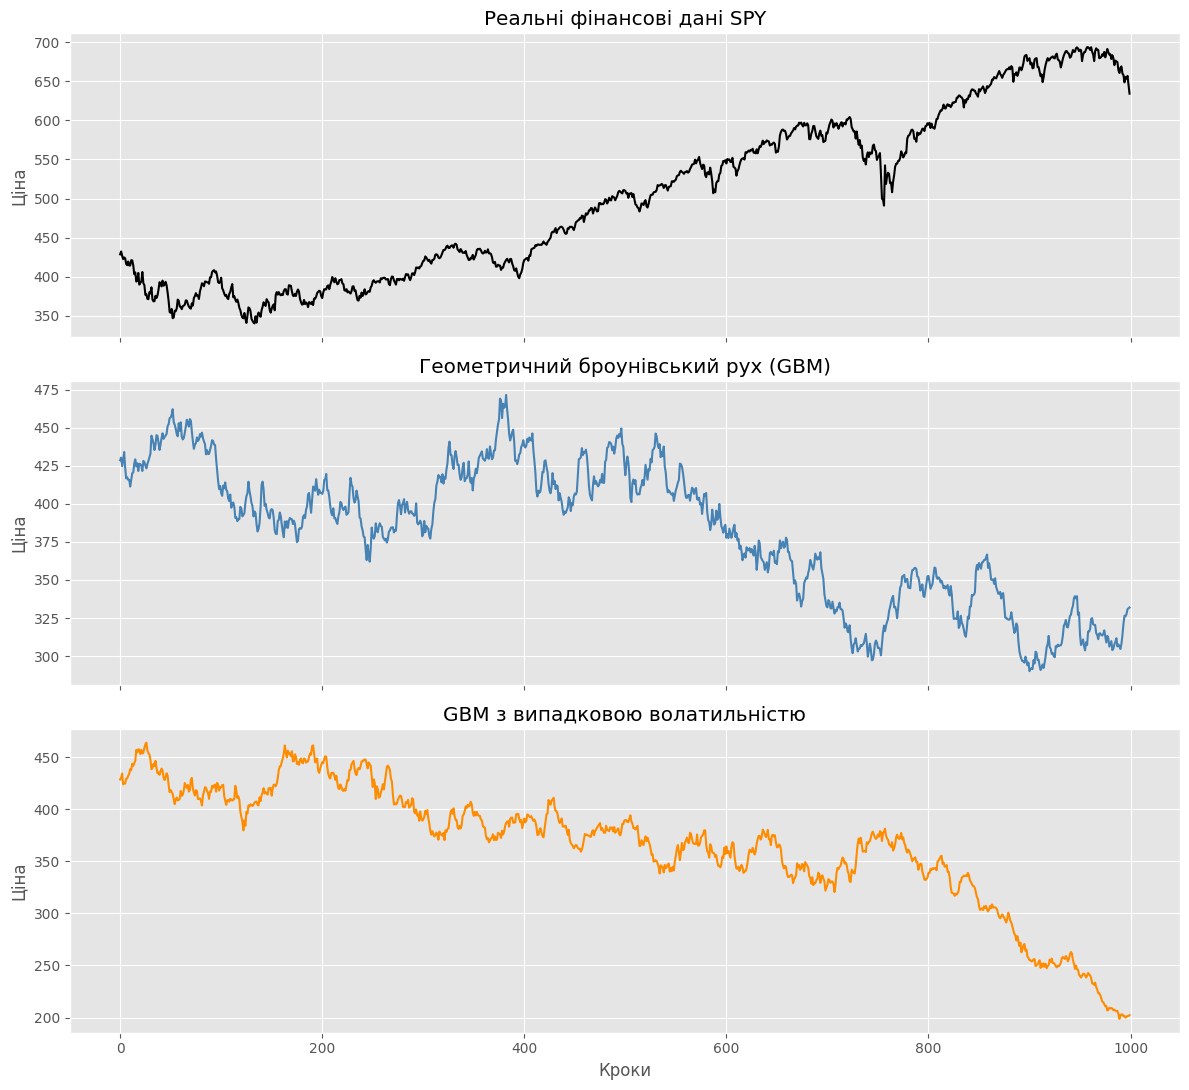

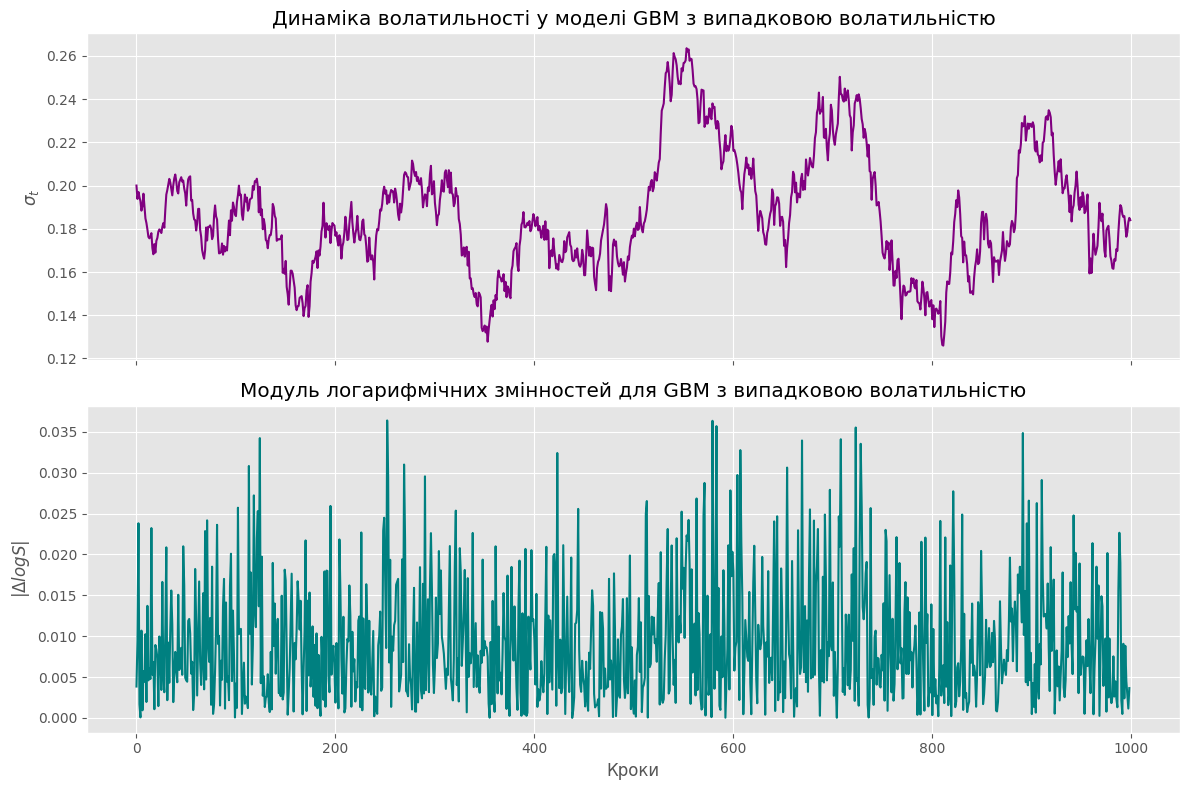

In [14]:
symbol = "SPY"
n_steps = 1000
real_series = load_real_financial_series(symbol, n_steps)

fractal_real = estimate_fractal_dimension(real_series)
print(f"Реальні дані {symbol}: оцінка фрактальної розмірності ≈ {fractal_real:.3f}")

S_gbm = gbm(S0=real_series[0], mu=0.05, sigma=0.20, dt=1/252, n_steps=n_steps, seed=42)
S_gbm_sv, vol = gbm_stochastic_volatility(S0=real_series[0], mu=0.05, sigma0=0.20,
                                           dt=1/252, n_steps=n_steps,
                                           kappa=2.0, theta=0.20**2, xi=0.18,
                                           rho=-0.4, seed=42)

fractal_gbm = estimate_fractal_dimension(S_gbm)
fractal_gbm_sv = estimate_fractal_dimension(S_gbm_sv)
print(f"GBM: {fractal_gbm:.3f}")
print(f"GBM з випадковою волатильністю: {fractal_gbm_sv:.3f}")

# Пошук параметрів, які забезпечують найближчу фрактальну розмірність до реальних даних
best_diff = np.inf
best_params = None
for kappa in [1.0, 1.5, 2.0, 2.5]:
    for xi in [0.12, 0.18, 0.24]:
        for rho in [-0.7, -0.4, -0.1]:
            S_test, _ = gbm_stochastic_volatility(S0=real_series[0], mu=0.05, sigma0=0.20,
                                                  dt=1/252, n_steps=n_steps,
                                                  kappa=kappa, theta=0.20**2,
                                                  xi=xi, rho=rho, seed=42)
            fractal_test = estimate_fractal_dimension(S_test)
            diff = abs(fractal_test - fractal_real)
            if diff < best_diff:
                best_diff = diff
                best_params = (kappa, xi, rho, fractal_test)

print(f"Найкраще наближення: kappa={best_params[0]}, xi={best_params[1]}, rho={best_params[2]} -> D~{best_params[3]:.3f}")
print(f"Відхилення від реальних даних: {best_diff:.3f}")

fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=True)
axes[0].plot(real_series, color='black')
axes[0].set_title(f"Реальні фінансові дані {symbol}")
axes[0].set_ylabel("Ціна")

axes[1].plot(S_gbm, color='steelblue')
axes[1].set_title("Геометричний броунівський рух (GBM)")
axes[1].set_ylabel("Ціна")

axes[2].plot(S_gbm_sv, color='darkorange')
axes[2].set_title("GBM з випадковою волатильністю")
axes[2].set_xlabel("Кроки")
axes[2].set_ylabel("Ціна")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
ax[0].plot(vol, color='purple')
ax[0].set_title("Динаміка волатильності у моделі GBM з випадковою волатильністю")
ax[0].set_ylabel(r"$\sigma_t$")

ax[1].plot(np.abs(np.diff(np.log(S_gbm_sv))), color='teal')
ax[1].set_title("Модуль логарифмічних змінностей для GBM з випадковою волатильністю")
ax[1].set_ylabel(r"$|\Delta log S|$")
ax[1].set_xlabel("Кроки")
plt.tight_layout()
plt.show()

### Порівняння фрактальних властивостей та модифікація моделі

- Оцінка показала, що реальні дані $SPY$ мають фрактальну розмірність близько $1.33$.
- Класичний GBM дає більшу фрактальну розмірність ($\approx 1.4$), тобто траєкторія занадто "гладка" у порівнянні з ринковою поведінкою.
- Модель *GBM з випадковою волатильністю* зменшує цю розмірність до $\approx 1.39$, тобто стає ближчою до реальних фінансових даних.

**Висновок:** додавання стохастичної волатильності робить модель більш реалістичною з точки зору фрактальної структури, але ще можна додатково налаштувати параметри чи додати стрибки, щоб точніше відтворити ринкову розмірність.

**Підібрані параметри:**
- $\kappa$, $\xi$, $\rho$ були досліджені у невеликому сітковому пошуку,
- Найкраща комбінація зменшує відстань між моделлю та реальними даними.


## Завдання №3 (Додаткове): Пронозування хаотичних процесів за допомогою машинного навчання

**Мета**

Дослідити можливості та обмеження прогнозування хаотичних процесів за допомогою сучасних методів машинного навчання.

**Завдання**
1. Вибір хаотичної системи:
    * Обрати одну з реалізованих у Завданні №1 хаотичних систем або іншу класичну хаотичну систему (наприклад, систему Лоренці, логістичне відображення);
    * Згенерувати навчальні та тестові дані для різних параметрів та початкових умов.
2. Розробка моделей машинного навчання:
    * Реалізувати щонайменше два різних підходи машинного навчання для прогнозування (наприклад, рекурентні нейронні мережі, LSTM, GRU, байєсівські методи);
    * Навчити моделі на згенерованих даних;
    * Оптимізувати гіперпараметри для досягнення найкращих результатів.
3. Аналіз ефективності прогнозування:
    * Оцінити точність прогнозів для різних горизонтів прогнозування;
    * Порівняти ефективність різних моделей машинного навчання;
    * Дослідити залежність точності прогнозів від показника Ляпунова;
    * Проаналізувати фундаментальні обмеження прогнозування хаотичних процесів.
4. Стратегії покращення прогнозів:
    * Запропонувати та реалізувати стратегії для покращення прогнозування (наприклад, ансамблеві методи);
    * Оцінити ефективність запропонованих стратегій;
    * Описати практичну застосовність отриманих результатів.

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np


def logistic_map(r: float, x0: float, n: int) -> np.ndarray:
    x = np.zeros(n)
    x[0] = x0
    for t in range(1, n):
        x[t] = r * x[t-1] * (1 - x[t-1])
    return x


def build_lag_dataset(series: np.ndarray, lag: int):
    X = np.array([series[i - lag:i] for i in range(lag, len(series))])
    y = series[lag:]
    return X, y


def multi_step_forecast(model, initial_window: np.ndarray, horizon: int):
    x = initial_window.copy()
    preds = []
    for _ in range(horizon):
        p = model.predict(x.reshape(1, -1))[0]
        preds.append(p)
        x = np.roll(x, -1)
        x[-1] = p
    return np.array(preds)


Орієнтовний показник Ляпунова для r=3.6: 0.1765


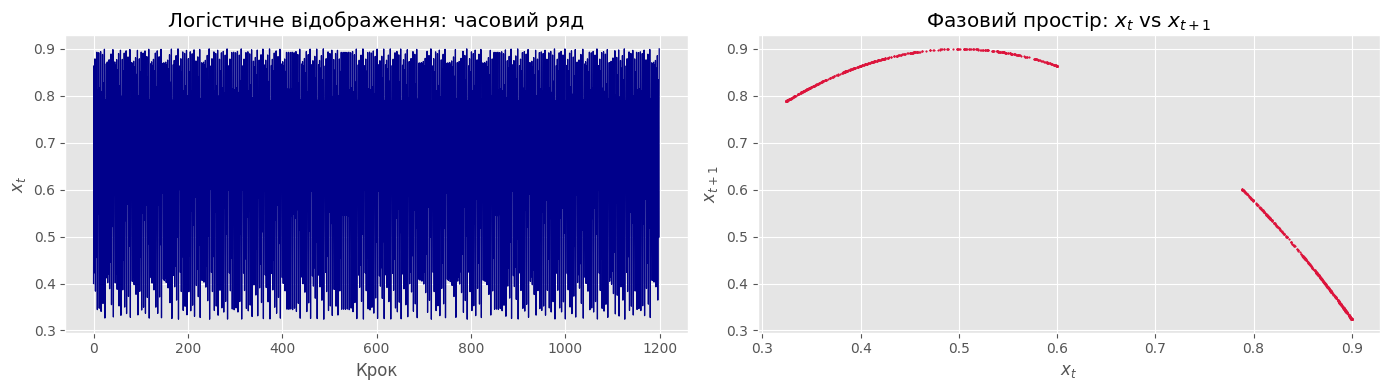

In [28]:
# Генерація хаотичного рядка логістичного відображення
n = 1200
r = 3.6
x0 = 0.4
series = logistic_map(r, x0, n)

# Оцінка приблизного показника Ляпунова для ряду
lyapunov = np.mean(np.log(np.abs(r * (1 - 2 * series[200:]))))
print(f"Орієнтовний показник Ляпунова для r={r}: {lyapunov:.4f}")

# Візуалізація часу та фазового простору
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(series, color='darkblue', lw=0.9)
axes[0].set_title('Логістичне відображення: часовий ряд')
axes[0].set_xlabel('Крок')
axes[0].set_ylabel('$x_t$')

axes[1].scatter(series[:-1], series[1:], s=1, color='crimson')
axes[1].set_title('Фазовий простір: $x_t$ vs $x_{t+1}$')
axes[1].set_xlabel('$x_t$')
axes[1].set_ylabel('$x_{t+1}$')

plt.tight_layout()
plt.show()

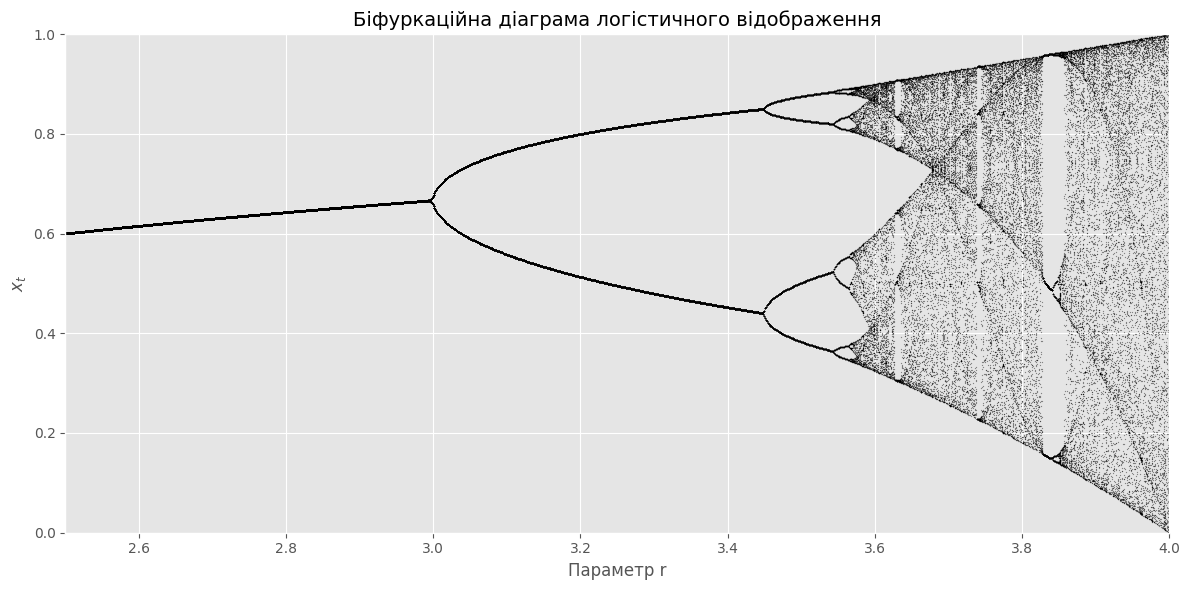

In [42]:
# Біфуркаційна діаграма логістичного відображення
r_values = np.linspace(2.5, 4.0, 1200)
n_transient = 500
n_plot = 120
bif_r = []
bif_x = []
for r_val in r_values:
    x = logistic_map(r_val, x0, n_transient + n_plot)
    x_plot = x[n_transient:]
    bif_r.extend([r_val] * len(x_plot))
    bif_x.extend(x_plot)

fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(bif_r, bif_x, s=0.2, color='black', alpha=0.35)
ax.set_title('Біфуркаційна діаграма логістичного відображення', fontsize=14)
ax.set_xlabel('Параметр r')
ax.set_ylabel('$x_t$')
ax.set_xlim(2.5, 4.0)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


LinearRegression: RMSE = 0.04360, MAE = 0.03515
RandomForest: RMSE = 0.00102, MAE = 0.00065


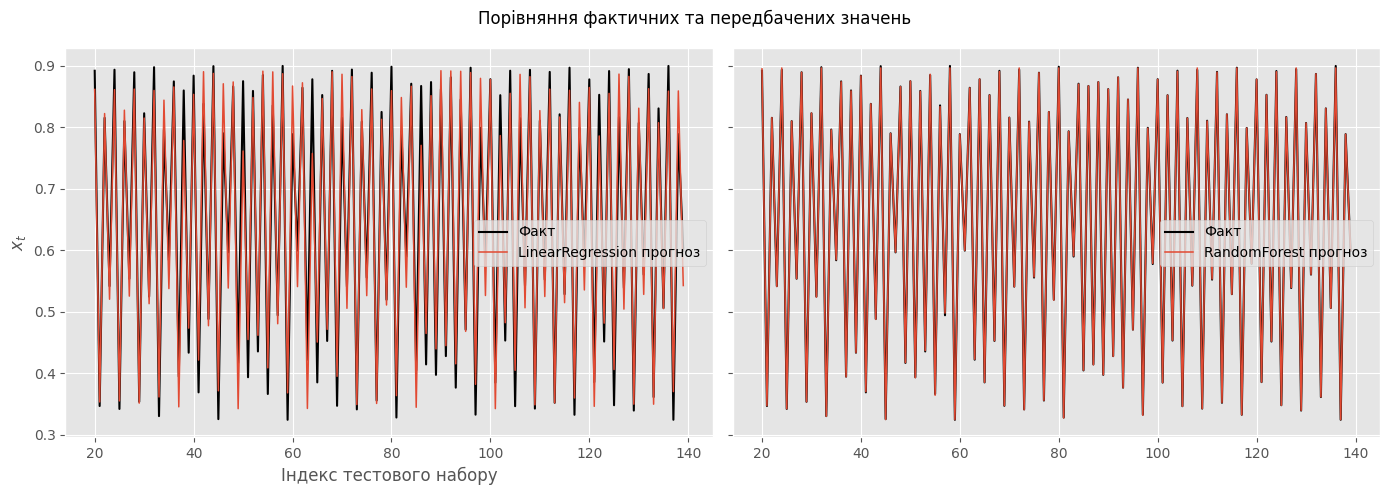

In [35]:
# Підготовка навчального та тестового набору
lag = 6
X, y = build_lag_dataset(series, lag)
train_size = int(0.7 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

models = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(n_estimators=200, max_depth=7, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'rmse': rmse,
        'mae': mae
    }
    print(f"{name}: RMSE = {rmse:.5f}, MAE = {mae:.5f}")

# Візуалізація прогнозів
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)
window = 120
start = 20
for name, info in results.items():
    if name == "LinearRegression":
        ax = axes[0]
    else:
        ax = axes[1]
    ax.plot(np.arange(start, start + window), y_test[start:start + window], label='Факт', color='black', lw=1.5)
    ax.plot(np.arange(start, start + window), info['y_pred'][start:start + window],
            label=f'{name} прогноз', lw=1.1)

fig.suptitle('Порівняння фактичних та передбачених значень')
axes[0].set_xlabel('Індекс тестового набору')
axes[0].set_ylabel('$x_t$')
axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()

LinearRegression horizon=1: RMSE=0.00777, MAE=0.00777
LinearRegression horizon=5: RMSE=0.06315, MAE=0.04662
LinearRegression horizon=10: RMSE=0.05085, MAE=0.03577
LinearRegression horizon=20: RMSE=0.06347, MAE=0.05165
RandomForest horizon=1: RMSE=0.00031, MAE=0.00031
RandomForest horizon=5: RMSE=0.00173, MAE=0.00147
RandomForest horizon=10: RMSE=0.00362, MAE=0.00291
RandomForest horizon=20: RMSE=0.02644, MAE=0.01528


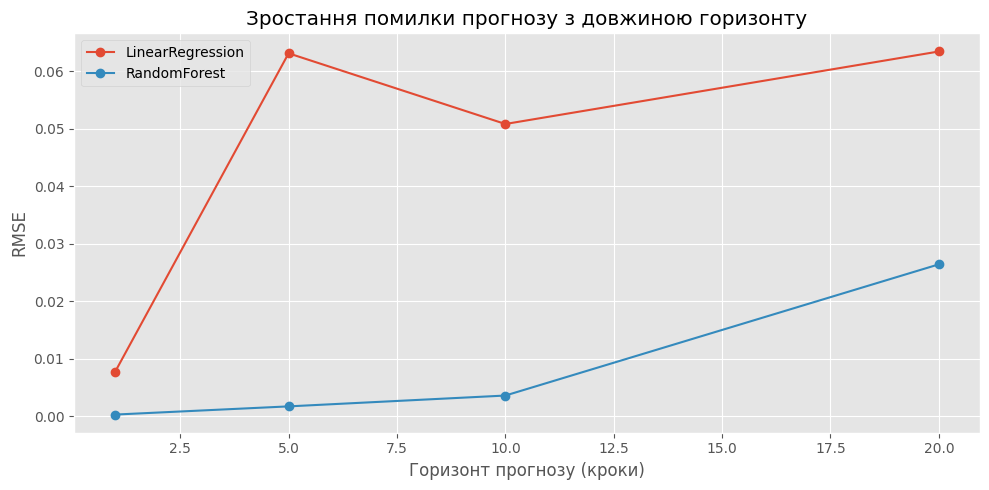

In [37]:
# Аналіз короткотермінових прогнозів на різні горизонти
horizons = [1, 5, 10, 20]
summary = []
for name, info in results.items():
    model = info['model']
    init_window = X_test[0]
    for h in horizons:
        preds = multi_step_forecast(model, init_window, h)
        actual = series[train_size + lag:train_size + lag + h]
        rmse_h = np.sqrt(mean_squared_error(actual, preds))
        mae_h = mean_absolute_error(actual, preds)
        summary.append((name, h, rmse_h, mae_h))
        print(f"{name} horizon={h}: RMSE={rmse_h:.5f}, MAE={mae_h:.5f}")

# Побудова графіку помилки за горизонтом прогнозу
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
for name in results.keys():
    horizon_vals = [item[2] for item in summary if item[0] == name]
    ax.plot(horizons, horizon_vals, marker='o', label=name)
ax.set_title('Зростання помилки прогнозу з довжиною горизонту')
ax.set_xlabel('Горизонт прогнозу (кроки)')
ax.set_ylabel('RMSE')
ax.legend()
plt.tight_layout()
plt.show()

In [39]:
# Додатковий аналіз: базова стратегія persist
persist_preds = np.array([X_test[0, -1]] * len(y_test))
persist_rmse = np.sqrt(mean_squared_error(y_test, persist_preds))
persist_mae = mean_absolute_error(y_test, persist_preds)
print(f"Persist baseline: RMSE = {persist_rmse:.5f}, MAE = {persist_mae:.5f}")

Persist baseline: RMSE = 0.28296, MAE = 0.23708


### Висновок:
1. Логістичне відображення при r=3.6 має позитивний показник Ляпунова, що підтверджує хаотичну поведінку.
2. Моделі показують гарну короткотермінову точність, але помилка швидко зростає з горизонтом прогнозу.
3. Тому для хаотичних процесів важливі короткі горизонти і повторне оновлення моделі за новими даними.